In [ ]:
!pip install scanpy==1.9.3 anndata==0.8.0
!pip install scikit-learn
!pip install matplotlib
!pip install pandas
!pip install numpy
!pip install harmonypy
!pip install scvi-tools

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 85.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 96.1/96.1 kB 12.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.6/87.6 kB 11.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 4.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 9.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 11.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 662.1/662.1 kB 40.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 853.6/853.6 kB 59.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 72.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 174.3/174.3 kB 12.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 92.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 151.9/151.9 kB 20.0 MB/s eta 0:00:00
   

In [ ]:
import scanpy as sc
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from matplotlib import pyplot as plt
import pandas as pd
import numpy as np
from sklearn.neighbors import KNeighborsClassifier
import seaborn as sns

In [ ]:
# mount drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Dataset

In [ ]:
# import anndata as ad

data_path = "/content/drive/MyDrive/GP_datasets/Lung_embeddings_uce.h5ada"


In [ ]:
# read adata
adata = sc.read_h5ad(data_path)

In [ ]:
print(adata)

AnnData object with n_obs × n_vars = 65129 × 12814
    obs: 'cell_type', 'dataset', 'source', 'n_genes'
    var: 'n_cells'
    uns: 'cell_type_colors', 'dataset_colors', 'neighbors', 'pca', 'umap'
    obsm: 'X_pca', 'X_uce', 'X_umap'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'


In [ ]:
# check cell_types
adata.obs['cell_type'].value_counts()
print(adata.obs)

                                        cell_type   dataset  \
AAACCTGGTTGTGGCC-1-HCATisStab7509734  Endothelium  Dataset1   
AAACGGGAGAAGGGTA-1-HCATisStab7509734  Endothelium  Dataset1   
AAACGGGCACCAGCAC-1-HCATisStab7509734     Alveolar  Dataset1   
AAACGGGCACGGACAA-1-HCATisStab7509734     Alveolar  Dataset1   
AAACGGGCACTCTGTC-1-HCATisStab7509734  Endothelium  Dataset1   
...                                           ...       ...   
ASK454_TACAAAATATCG                        B cell  Dataset2   
ASK454_CTGATTCAGGCG                        B cell  Dataset2   
ASK454_GCTGGGAACCGA                        B cell  Dataset2   
ASK454_GAATCGCTGCCA                        B cell  Dataset2   
ASK454_GTGGCTTAGGTC                        B cell  Dataset2   

                                                    source  n_genes  
AAACCTGGTTGTGGCC-1-HCATisStab7509734  CZI/Human Cell Atlas      392  
AAACGGGAGAAGGGTA-1-HCATisStab7509734  CZI/Human Cell Atlas      388  
AAACGGGCACCAGCAC-1-HCATisStab7509

## Normalization

In [ ]:
# make sure there is a counts layer for scvi
adata.layers["counts"] = adata.X

In [ ]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

In [ ]:
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)
adata.raw = adata  # keep full dimension safe
sc.pp.highly_variable_genes(
    adata,
    n_top_genes=4000,
    flavor="seurat_v3",
    layer="counts",
    subset=True,
    batch_key="dataset",  #
)

In [ ]:
import scvi
import scanpy as sc

# Make sure categorical columns are string type
# adata.obs["donor_id"] = adata.obs["donor_id"].astype(str)

# Prepare AnnData for SCVI
scvi.model.SCVI.setup_anndata(
    adata,
    layer = "counts",
    batch_key="dataset",
)

In [ ]:
vae = scvi.model.SCVI(adata, n_layers=2, n_latent=30, gene_likelihood="nb")
vae.train(max_epochs=100, early_stopping=True)

INFO: GPU available: True (cuda), used: True
INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable Li

Training:   0%|          | 0/100 [00:00<?, ?it/s]

INFO: `Trainer.fit` stopped: `max_epochs=100` reached.
INFO: `Trainer.fit` stopped: `max_epochs=100` reached.
INFO:lightning.pytorch.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=100` reached.


In [ ]:
adata.obsm["X_scVI"] = vae.get_latent_representation()

In [ ]:
# save embeddings to drive
adata.write("/content/drive/MyDrive/GP_datasets/Lung_embeddings_scVI.h5ad")

In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import silhouette_score
from harmonypy import compute_lisi

def compute_silhouette_and_lisi(adata, label_keys, embed_key,k_lisi=30):

    X = adata.obsm[embed_key]
    metadata = adata.obs[label_keys]


    # Silhouette scores
    sil_scores = {}
    for key in label_keys:
        sil_scores[key] = silhouette_score(X, adata.obs[key].values)


    # Call compute_lisi
    lisi_scores = compute_lisi(X, metadata, label_colnames=label_keys)

    # Convert to DataFrame for easier handling
    lisi_df = pd.DataFrame(lisi_scores, columns=label_keys, index=adata.obs_names)

    # Combine results
    scores = {
        "silhouette": sil_scores,
        "lisi": lisi_df.median().to_dict()
    }

    return scores

In [ ]:
# "Label Transfer"

train_out = "/content/drive/MyDrive/GP_datasets/Lung_embeddings_scVI.h5ad"

adata = sc.read(train_out)

adata

AnnData object with n_obs × n_vars = 65129 × 4000
    obs: 'cell_type', 'dataset', 'source', 'n_genes', '_scvi_batch', '_scvi_labels'
    var: 'n_cells', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches'
    uns: '_scvi_manager_uuid', '_scvi_uuid', 'cell_type_colors', 'dataset_colors', 'hvg', 'log1p', 'neighbors', 'pca', 'umap'
    obsm: 'X_pca', 'X_scVI', 'X_uce', 'X_umap'
    varm: 'PCs'
    layers: 'counts'
    obsp: 'connectivities', 'distances'

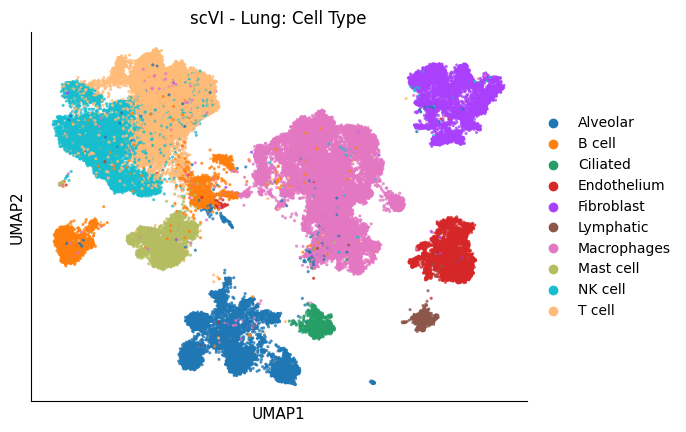

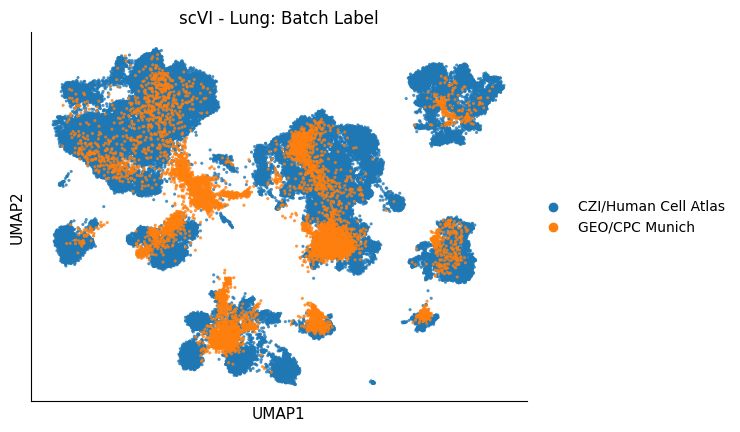

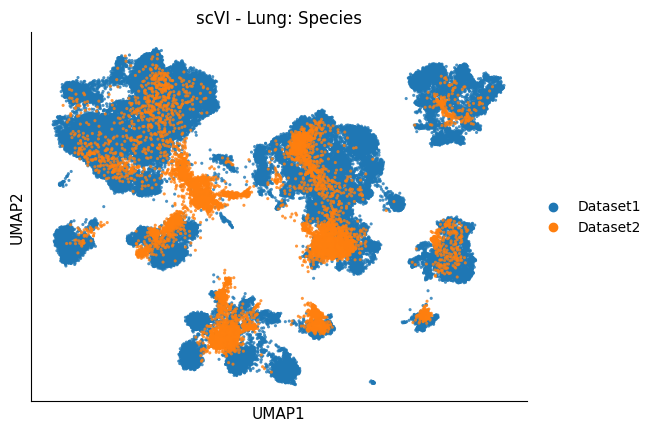

=== Logistic Regression ===
Accuracy: 0.8082267926625903
              precision    recall  f1-score   support

    Alveolar       0.71      0.88      0.79      1834
      B cell       0.75      0.14      0.23      1250
    Ciliated       0.98      0.97      0.97       433
 Endothelium       0.87      0.99      0.93       360
  Fibroblast       0.87      0.98      0.92       204
   Lymphatic       0.98      0.93      0.96       195
 Macrophages       0.87      0.95      0.91      2878
   Mast cell       0.97      0.97      0.97       660
     NK cell       0.48      0.79      0.60       354
      T cell       0.78      0.82      0.80       827

    accuracy                           0.81      8995
   macro avg       0.83      0.84      0.81      8995
weighted avg       0.81      0.81      0.78      8995



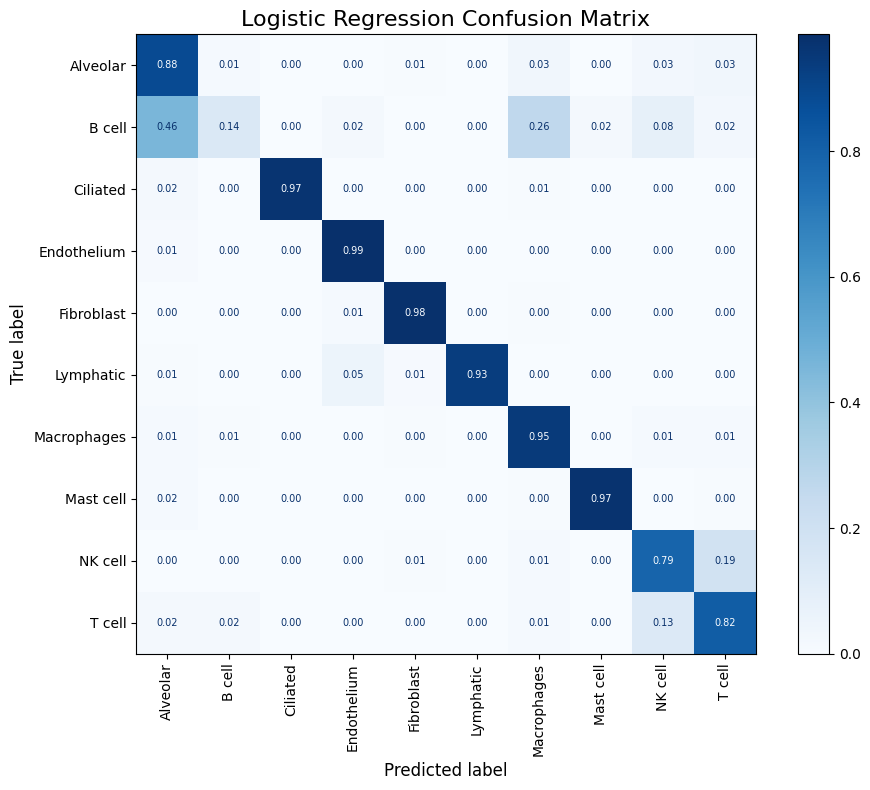


=== k-NN ===
Accuracy: 0.795775430794886
              precision    recall  f1-score   support

    Alveolar       0.81      0.86      0.83      1834
      B cell       0.63      0.07      0.13      1250
    Ciliated       0.99      0.93      0.96       433
 Endothelium       0.82      0.99      0.90       360
  Fibroblast       0.83      0.93      0.87       204
   Lymphatic       0.95      0.96      0.96       195
 Macrophages       0.82      0.95      0.88      2878
   Mast cell       0.85      0.98      0.91       660
     NK cell       0.58      0.77      0.66       354
      T cell       0.67      0.86      0.75       827

    accuracy                           0.80      8995
   macro avg       0.79      0.83      0.79      8995
weighted avg       0.78      0.80      0.75      8995



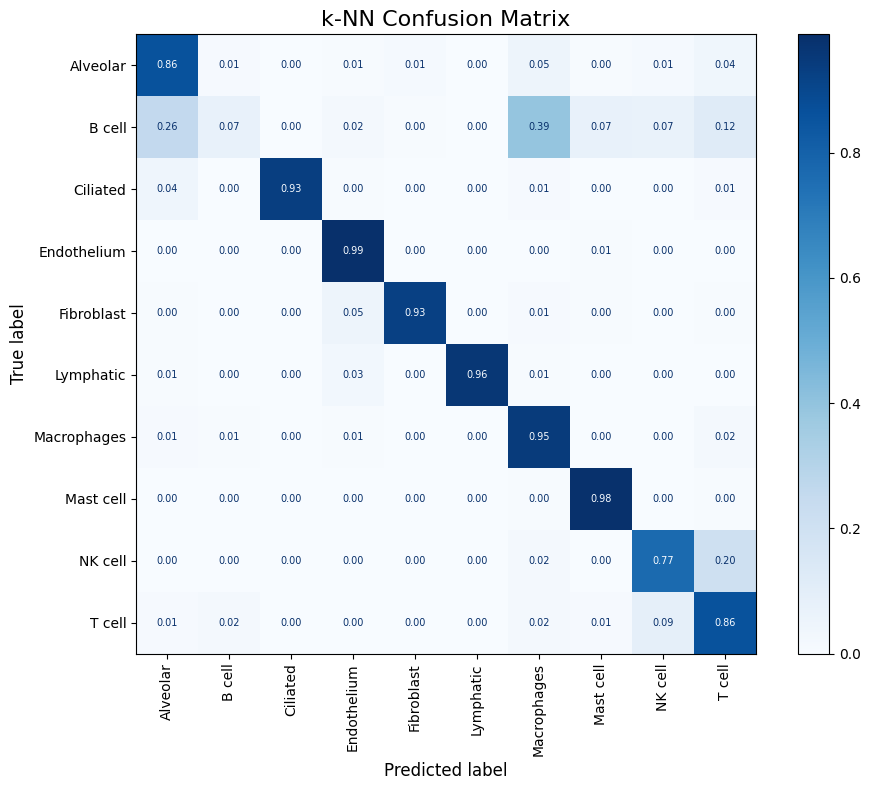

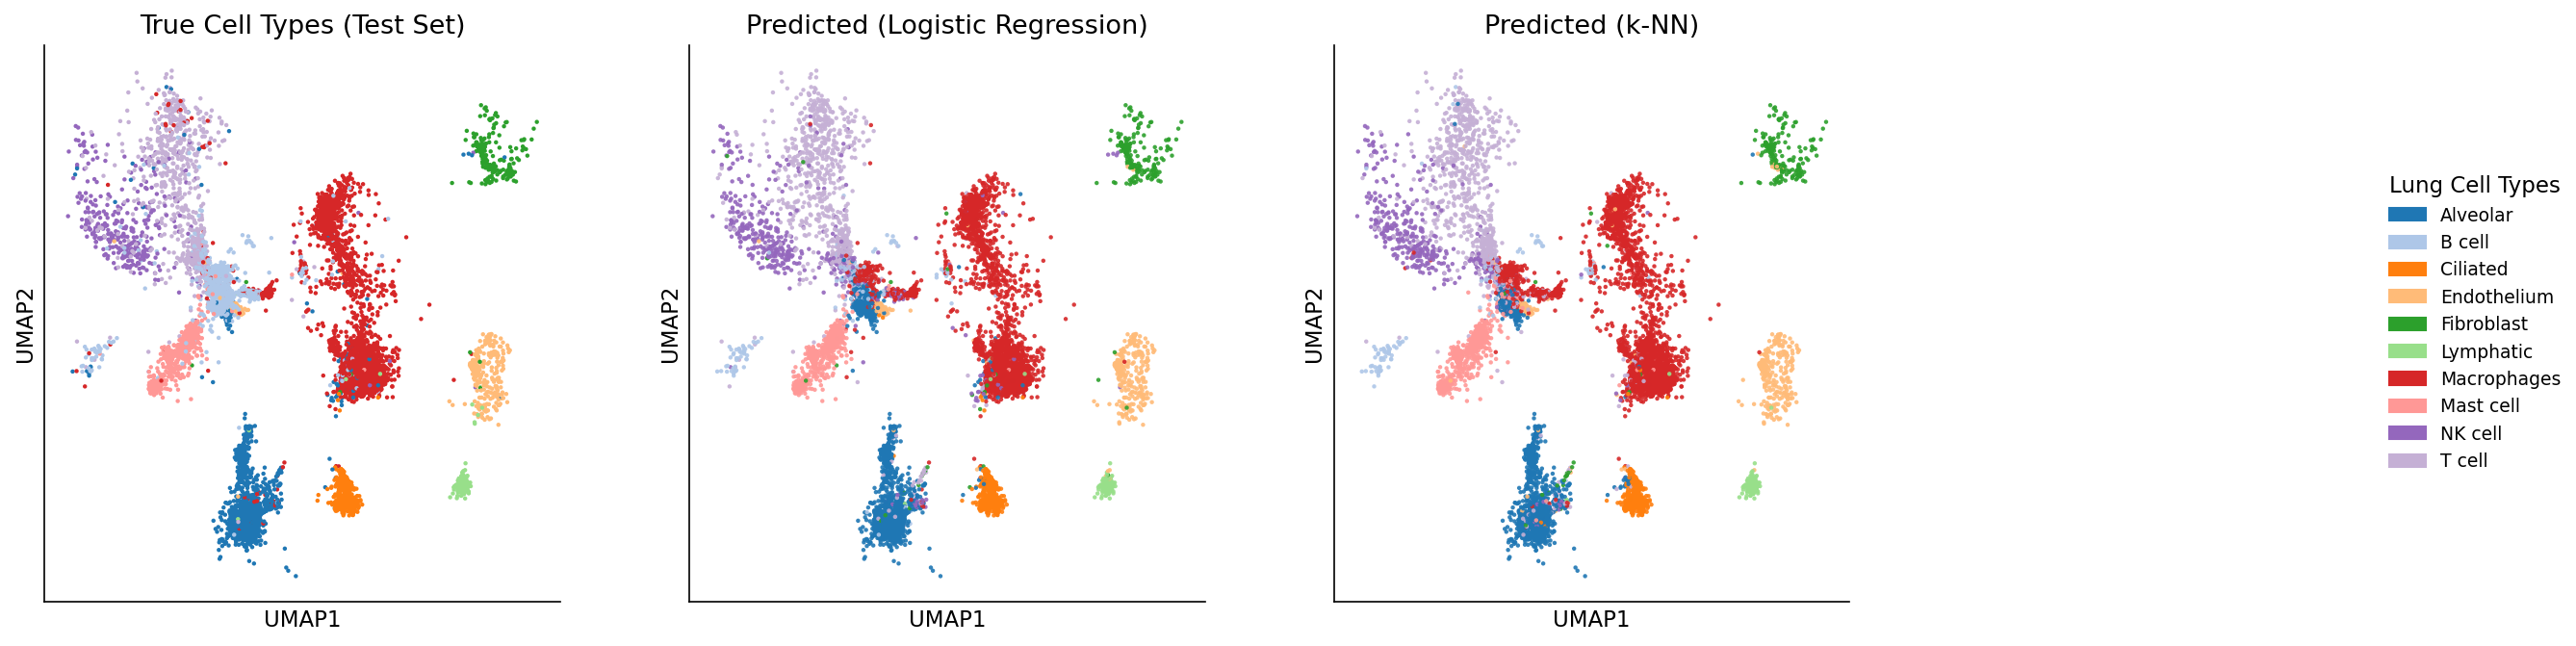

In [ ]:

## Visualization

from sklearn.metrics import ConfusionMatrixDisplay


sc.pp.neighbors(adata, use_rep="X_scVI")
sc.tl.umap(adata)

ax = sc.pl.umap(
    adata,
    color='cell_type',
    size=20,
    alpha=0.8,
    frameon=True,
    show=False,
    title="scVI - Lung: Cell Type"
)

ax.set_facecolor("white")
ax.set_xlabel("UMAP1", fontsize=11)
ax.set_ylabel("UMAP2", fontsize=11)

# Make axis lines visible
ax.spines[['left', 'bottom']].set_visible(True)

# Remove top/right box lines (clean style)
ax.spines[['top', 'right']].set_visible(False)

# Make axes black
ax.spines[['left', 'bottom']].set_color("black")

plt.show()

ax = sc.pl.umap(
    adata,
    color='source',
    size=20,
    alpha=0.8,
    frameon=True,
    show=False,
    title="scVI - Lung: Batch Label"
)

ax.set_facecolor("white")
ax.set_xlabel("UMAP1", fontsize=11)
ax.set_ylabel("UMAP2", fontsize=11)

# Make axis lines visible
ax.spines[['left', 'bottom']].set_visible(True)

# Remove top/right box lines (clean style)
ax.spines[['top', 'right']].set_visible(False)

# Make axes black
ax.spines[['left', 'bottom']].set_color("black")

plt.show()

ax = sc.pl.umap(
    adata,
    color='dataset',
    size=20,
    alpha=0.8,
    frameon=True,
    show=False,
    title="scVI - Lung: Species"
)

ax.set_facecolor("white")
ax.set_xlabel("UMAP1", fontsize=11)
ax.set_ylabel("UMAP2", fontsize=11)

# Make axis lines visible
ax.spines[['left', 'bottom']].set_visible(True)

# Remove top/right box lines (clean style)
ax.spines[['top', 'right']].set_visible(False)

# Make axes black
ax.spines[['left', 'bottom']].set_color("black")

plt.show()

## Build a cell-type classifier using Geneformer embeddings  3 batches for train and 1 for test

train_data = adata[adata.obs["dataset"] == "Dataset1"]
test_data  = adata[adata.obs["dataset"] == "Dataset2"]

X_train = train_data.obsm["X_scVI"]
X_test  = test_data.obsm["X_scVI"]

y_train = train_data.obs["cell_type"]
y_test  = test_data.obs["cell_type"]


# logistic regression
clf = LogisticRegression(max_iter=300, solver='lbfgs')

clf.fit(X_train, y_train)
y_pred_lr = clf.predict(X_test)

# KNN
knn = KNeighborsClassifier(
    n_neighbors=15,
    weights="distance",
    metric="cosine"
)

knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)

def plot_cm(y_true, y_pred, title):
    labels = np.unique(y_true)
    cm = confusion_matrix(y_true, y_pred, labels=labels, normalize="true")

    fig, ax = plt.subplots(figsize=(10, 8), dpi=100)

    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                  display_labels=labels)

    disp.plot(
        ax=ax,
        cmap="Blues",
        xticks_rotation=90,
        values_format=".2f",
        colorbar=True
    )

    # Make text smaller
    for text in ax.texts:
        text.set_fontsize(7)

    plt.title(title, fontsize=16)
    plt.xlabel("Predicted label", fontsize=12)
    plt.ylabel("True label", fontsize=12)

    plt.tight_layout()
    plt.show()

print("=== Logistic Regression ===")
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))
plot_cm(y_test, y_pred_lr, "Logistic Regression Confusion Matrix")


print("\n=== k-NN ===")
print("Accuracy:", accuracy_score(y_test, y_pred_knn))
print(classification_report(y_test, y_pred_knn))
plot_cm(y_test, y_pred_knn, "k-NN Confusion Matrix")

# Attach predictions to test dataset
test_data.obs["y_pred_lr"] = y_pred_lr
test_data.obs["y_pred_knn"] = y_pred_knn

# Fill missing values
test_data.obs["y_pred_lr"] = test_data.obs["y_pred_lr"].astype(str).fillna("Unassigned")
test_data.obs["y_pred_knn"] = test_data.obs["y_pred_knn"].astype(str).fillna("Unassigned")

# Convert to categorical
test_data.obs["cell_type"] = test_data.obs["cell_type"].astype("category") # Changed from celltype to cell_type
test_data.obs["y_pred_lr"] = test_data.obs["y_pred_lr"].astype("category")
test_data.obs["y_pred_knn"] = test_data.obs["y_pred_knn"].astype("category")

# Unified label set
all_labels = sorted(
    set(test_data.obs["cell_type"].cat.categories)
    | set(test_data.obs["y_pred_lr"].cat.categories)
    | set(test_data.obs["y_pred_knn"].cat.categories)
)

# Force same category order
test_data.obs["cell_type"] = test_data.obs["cell_type"].cat.set_categories(all_labels)
test_data.obs["y_pred_lr"] = test_data.obs["y_pred_lr"].cat.set_categories(all_labels)
test_data.obs["y_pred_knn"] = test_data.obs["y_pred_knn"].cat.set_categories(all_labels)

# Color map
palette = sc.pl.palettes.vega_20
color_map = {label: palette[i % len(palette)] for i, label in enumerate(all_labels)}
color_map["Unassigned"] = "lightgray"

# Plot
fig, axes = plt.subplots(1, 3, figsize=(20, 5), dpi=150)

common_kwargs = dict(
    show=False,
    size=18,
    frameon=True,
    palette=color_map
)

# True labels
sc.pl.umap(test_data, color="cell_type", ax=axes[0], **common_kwargs)
axes[0].set_title("True Cell Types (Test Set)", fontsize=13)

# Logistic Regression predictions
sc.pl.umap(test_data, color="y_pred_lr", ax=axes[1], alpha=0.9, **common_kwargs)
axes[1].set_title("Predicted (Logistic Regression)", fontsize=13)

# KNN predictions
sc.pl.umap(test_data, color="y_pred_knn", ax=axes[2], alpha=0.9, **common_kwargs)
axes[2].set_title("Predicted (k-NN)", fontsize=13)

# Remove auto legends
for ax in axes:
    # Remove auto legend
    if ax.legend_:
        ax.legend_.remove()

    # Force white background
    ax.set_facecolor("white")

    # Axis labels
    ax.set_xlabel("UMAP1", fontsize=11)
    ax.set_ylabel("UMAP2", fontsize=11)

    # Make axis lines visible
    ax.spines[['left', 'bottom']].set_visible(True)

    # Remove top/right box lines (clean style)
    ax.spines[['top', 'right']].set_visible(False)

    # Make axes black
    ax.spines[['left', 'bottom']].set_color("black")

    # Ticks
    ax.tick_params(
        axis='both',
        which='major',
        labelsize=9,
        colors='black'
    )
# Single clean legend
from matplotlib.patches import Patch
handles = [Patch(color=color_map[label], label=label) for label in all_labels]
fig.legend(
    handles=handles,
    title="Lung Cell Types",
    loc="center right",
    frameon=False,
    fontsize=9,
    title_fontsize=11,
    ncol=1
)
plt.subplots_adjust(right=0.75, wspace=0.25)
# plt.tight_layout()
plt.show()

In [ ]:
label_keys = ["cell_type", "dataset"]
# Compute scores
scores = compute_silhouette_and_lisi(adata, label_keys, embed_key="X_scVI", k_lisi=30)
print("Silhouette Scores:", scores["silhouette"])
print("LISI Scores:", scores["lisi"])


Silhouette Scores: {'cell_type': np.float32(0.09225742), 'dataset': np.float32(0.024255702)}
LISI Scores: {'cell_type': 1.002822426537379, 'dataset': 1.0000000000000004}
